# Reliance Inc. Data Extraction Pipeline
## Steel Price Forecasting & Supply Chain Analytics

**Project**: Predictive/Prescriptive Analytics Platform  
**Date**: October 23, 2025  
**Purpose**: Extract and process data from FRED, Census, EIA, and Freight sources

---

## 1. Setup & Dependencies

## API Endpoint Summary

This notebook uses **verified and corrected** API endpoints for all data sources:

### ✅ Census Bureau Construction Spending (VIP)
- **Correct Endpoint**: `https://api.census.gov/data/timeseries/eits/vip`
- **Parameters**: `get`, `for` (empty string for national), `time` (from+YYYY-MM format), `key`
- **Note**: Previous specification incorrectly used `/data/{year}/construction/c30/totpage`
- **Variables**: cell_value, time_slot_id, category_code, data_type_code, seasonally_adj
- **Documentation**: https://www.census.gov/data/developers/data-sets/economic-indicators.html

### ✅ Census Bureau M3 (Manufacturers' Shipments)
- **Correct Endpoint**: `https://api.census.gov/data/timeseries/eits/m3`
- **Parameters**: `get`, `for=US` (required), `time`, `category_code`, `key`
- **Data Types**: SM (Shipments), NO (New Orders), UO (Unfilled Orders), TI (Total Inventory)
- **NAICS 331**: Primary Metals (steel-related manufacturing)
- **Documentation**: https://www.census.gov/manufacturing/m3/

### ✅ FRED API (Verified as Correct)
- **Endpoint**: `https://api.stlouisfed.org/fred/series/observations`
- **Parameters**: `series_id`, `api_key`, `file_type=json`, `observation_start`
- **Rate Limit**: 120 requests/minute with API key
- **Series**: TRUCKD11 (Truck Tonnage), TSIFRGHT (Freight TSI), WPU1017 (Steel PPI)
- **Documentation**: https://fred.stlouisfed.org/docs/api/fred/

### 🔑 API Key Requirements
- **Census**: Free registration, unlimited queries with key (500/day without)
- **FRED**: Free registration, 120 requests/min
- **EIA**: Free registration for diesel prices and emissions data

---

In [69]:
# Import required libraries
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import json
import os
from pathlib import Path
from urllib.parse import urlencode
import warnings
warnings.filterwarnings('ignore')

# For data validation
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Configuration & API Keys

**Important**: Register for API keys at:
- FRED: https://fredaccount.stlouisfed.org/apikeys (120 requests/min with key)
- Census: https://api.census.gov/data/key_signup.html (unlimited with key vs 500/day without)
- EIA: https://www.eia.gov/opendata/

**API Documentation:**
- FRED API: https://fred.stlouisfed.org/docs/api/fred/
- Census EITS: https://www.census.gov/data/developers/data-sets/economic-indicators.html
- Census VIP Variables: https://www.census.gov/econ/currentdata/datasets/vip-api.xml
- Census M3 Variables: https://www.census.gov/econ/currentdata/datasets/m3-api.xml

In [70]:
# API Configuration
# OPTION 1: Set API keys directly (for testing)
API_KEYS = {
    'FRED': 'YOUR_FRED_API_KEY_HERE',
    'CENSUS': '87f911d32c71d4325b27bea0d9d72358be85825c',
    'EIA': 'YOUR_EIA_API_KEY_HERE'
}

# OPTION 2: Load from environment variables (recommended for production)
# API_KEYS = {
#     'FRED': os.getenv('FRED_API_KEY'),
#     'CENSUS': os.getenv('CENSUS_API_KEY'),
#     'EIA': os.getenv('EIA_API_KEY')
# }

# Date range for initial extraction
START_DATE = '2025-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

# Output directory for extracted data
OUTPUT_DIR = Path('extracted_data')
OUTPUT_DIR.mkdir(exist_ok=True)

# Audit log
AUDIT_LOG = []

print(f"✓ Configuration loaded")
print(f"  Date Range: {START_DATE} to {END_DATE}")
print(f"  Output Directory: {OUTPUT_DIR}")

✓ Configuration loaded
  Date Range: 2025-01-01 to 2025-10-23
  Output Directory: extracted_data


## 3. Helper Functions

In [77]:
def log_extraction(source, status, records=0, error_msg=None):
    """Log extraction attempt to audit log."""
    AUDIT_LOG.append({
        'timestamp': datetime.now(),
        'source': source,
        'status': status,
        'records': records,
        'error': error_msg
    })

def retry_request(url, params=None, max_retries=3, backoff_factor=2):
    """Make API request with exponential backoff retry logic."""
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            return response
        except requests.exceptions.RequestException as e:
            if attempt == max_retries - 1:
                raise
            wait_time = backoff_factor ** attempt
            print(f"  Retry attempt {attempt + 1} after {wait_time}s...")
            time.sleep(wait_time)

def validate_date_continuity(df, date_col='date', max_gap_days=45):
    """Check for gaps in time series data."""
    df = df.sort_values(date_col)
    df[date_col] = pd.to_datetime(df[date_col])
    gaps = df[date_col].diff()
    large_gaps = gaps[gaps > pd.Timedelta(days=max_gap_days)]
    
    if len(large_gaps) > 0:
        print(f"  ⚠️  Found {len(large_gaps)} gap(s) > {max_gap_days} days")
        return False, large_gaps
    return True, None

def validate_value_range(df, value_col='value', min_val=None, max_val=None):
    """Validate values are within expected range."""
    issues = []
    
    # Check for nulls
    null_count = df[value_col].isna().sum()
    if null_count > 0:
        issues.append(f"Found {null_count} null values")
    
    # Check range
    if min_val is not None:
        below_min = (df[value_col] < min_val).sum()
        if below_min > 0:
            issues.append(f"Found {below_min} values < {min_val}")
    
    if max_val is not None:
        above_max = (df[value_col] > max_val).sum()
        if above_max > 0:
            issues.append(f"Found {above_max} values > {max_val}")
    
    return len(issues) == 0, issues

def detect_outliers(df, value_col='value', threshold_pct=20):
    """Detect outliers based on month-over-month changes."""
    df = df.sort_values('date').copy()
    df['pct_change'] = df[value_col].pct_change() * 100
    outliers = df[df['pct_change'].abs() > threshold_pct]
    
    if len(outliers) > 0:
        print(f"  ⚠️  Found {len(outliers)} observation(s) with >{threshold_pct}% change")
        return outliers
    return None

def save_data(df, filename, format='csv'):
    """Save dataframe to file."""
    filepath = OUTPUT_DIR / filename
    
    if format == 'csv':
        df.to_csv(filepath, index=False)
    elif format == 'parquet':
        df.to_parquet(filepath, index=False)
    elif format == 'json':
        df.to_json(filepath, orient='records', date_format='iso')
    
    print(f"  ✓ Saved to {filepath}")
    return filepath

print("✓ Helper functions defined")

✓ Helper functions defined


In [78]:
from urllib.parse import urlencode, quote

def retry_request(url, params=None, max_retries=3, backoff_factor=2):
    """
    Make API request with exponential backoff retry logic.

    Fix for Census EITS: ensure 'time' uses '%20' (not '+') so 'from YYYY-MM'
    becomes 'from%20YYYY-MM'.
    """
    def build_url(u, p):
        if not p:
            return u
        p = dict(p)
        # Pre-encode only 'time'
        if 'time' in p and isinstance(p['time'], str) and 'from ' in p['time']:
            p['time'] = p['time'].replace('from ', 'from%20')
        # Encode with quote (not quote_plus) so spaces -> %20
        qs = urlencode(p, doseq=True, quote_via=quote, safe=',')
        return f"{u}?{qs}"

    for attempt in range(max_retries):
        try:
            final_url = build_url(url, params)
            response = requests.get(final_url, timeout=30)
            response.raise_for_status()
            return response
        except requests.exceptions.RequestException as e:
            if attempt == max_retries - 1:
                raise
            wait_time = backoff_factor ** attempt
            print(f"  Retry attempt {attempt + 1} after {wait_time}s due to: {e}")
            time.sleep(wait_time)

---
# SOURCE A: FRED Economic Data

def extract_fred_series(series_id, api_key, start_date=START_DATE):
    """
    Extract time series data from FRED API.
    
    Parameters:
    -----------
    series_id : str
        FRED series identifier (e.g., 'WPU1017')
    api_key : str
        FRED API key
    start_date : str
        Start date in YYYY-MM-DD format
    
    Returns:
    --------
    pd.DataFrame : Time series data
    """
    url = "https://api.stlouisfed.org/fred/series/observations"
    
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start_date
    }
    
    try:
        print(f"\nExtracting FRED series: {series_id}")
        response = retry_request(url, params)
        data = response.json()
        
        if 'observations' not in data:
            raise ValueError(f"No observations found for {series_id}")
        
        observations = data['observations']
        df = pd.DataFrame(observations)
        
        # Data transformation
        df['date'] = pd.to_datetime(df['date'])
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df['series_id'] = series_id
        df['source'] = 'FRED'
        df['extraction_timestamp'] = datetime.now()
        
        # Select and reorder columns
        df = df[['series_id', 'date', 'value', 'realtime_start', 'realtime_end', 
                 'source', 'extraction_timestamp']]
        
        # Remove rows where value is null (indicated by '.')
        df = df[df['value'].notna()]
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        
        log_extraction(f'FRED_{series_id}', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting {series_id}: {e}")
        log_extraction(f'FRED_{series_id}', 'FAILED', 0, str(e))
        return None

# ENHANCED: Define FRED series to extract (expanded from 4 to 7 series)
FRED_SERIES = {
    'WPU1017': 'Producer Price Index - Steel Mill Products',
    'PCU331331': 'Primary Metal Manufacturing PPI',
    'TRUCKD11': 'Truck Tonnage Index (ATA)',
    'RAILFRTCARLOADSD11': 'Rail Carloads of All Freight',
    'TSIFRGHT': 'Freight Transportation Services Index',
    'IPMAN': 'Industrial Production: Manufacturing',
    'INDPRO': 'Industrial Production Index'
}

print(f"\n{'='*60}")
print("SOURCE A: FRED ECONOMIC DATA EXTRACTION (ENHANCED)")
print(f"{'='*60}")

In [37]:
def extract_fred_series(series_id, api_key, start_date=START_DATE):
    """
    Extract time series data from FRED API.
    
    Parameters:
    -----------
    series_id : str
        FRED series identifier (e.g., 'WPU1017')
    api_key : str
        FRED API key
    start_date : str
        Start date in YYYY-MM-DD format
    
    Returns:
    --------
    pd.DataFrame : Time series data
    """
    url = "https://api.stlouisfed.org/fred/series/observations"
    
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start_date
    }
    
    try:
        print(f"\nExtracting FRED series: {series_id}")
        response = retry_request(url, params)
        data = response.json()
        
        if 'observations' not in data:
            raise ValueError(f"No observations found for {series_id}")
        
        observations = data['observations']
        df = pd.DataFrame(observations)
        
        # Data transformation
        df['date'] = pd.to_datetime(df['date'])
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df['series_id'] = series_id
        df['source'] = 'FRED'
        df['extraction_timestamp'] = datetime.now()
        
        # Select and reorder columns
        df = df[['series_id', 'date', 'value', 'realtime_start', 'realtime_end', 
                 'source', 'extraction_timestamp']]
        
        # Remove rows where value is null (indicated by '.')
        df = df[df['value'].notna()]
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        
        log_extraction(f'FRED_{series_id}', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting {series_id}: {e}")
        log_extraction(f'FRED_{series_id}', 'FAILED', 0, str(e))
        return None

# Define FRED series to extract
FRED_SERIES = {
    'WPU1017': 'Producer Price Index - Steel Mill Products',
    'PCU331331': 'Primary Metal Manufacturing PPI',
    'TRUCKD11': 'Truck Tonnage Index (ATA)',
    'RAILFRTCARLOADSD11': 'Rail Carloads of All Freight'
}

print(f"\n{'='*60}")
print("SOURCE A: FRED ECONOMIC DATA EXTRACTION")
print(f"{'='*60}")


SOURCE A: FRED ECONOMIC DATA EXTRACTION


In [38]:
# Extract all FRED series
fred_data = {}

for series_id, description in FRED_SERIES.items():
    df = extract_fred_series(series_id, API_KEYS['FRED'])
    if df is not None:
        fred_data[series_id] = df
        # Save individual series
        save_data(df, f'fred_{series_id}.csv')

# Combine all FRED series into one dataframe
if fred_data:
    fred_combined = pd.concat(fred_data.values(), ignore_index=True)
    save_data(fred_combined, 'fred_all_series.csv')
    print(f"\n✓ Total FRED records extracted: {len(fred_combined)}")
else:
    print("\n✗ No FRED data extracted")


Extracting FRED series: WPU1017
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
  ✗ Error extracting WPU1017: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=WPU1017&api_key=YOUR_FRED_API_KEY_HERE&file_type=json&observation_start=2015-01-01

Extracting FRED series: PCU331331
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
  ✗ Error extracting PCU331331: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=PCU331331&api_key=YOUR_FRED_API_KEY_HERE&file_type=json&observation_start=2015-01-01

Extracting FRED series: TRUCKD11
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
  ✗ Error extracting TRUCKD11: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=TRUCKD11&api_key=YOUR_FRED_API_KEY_HERE&file_type=json&observation_start=2015-01-01

Extracting FRED series: RAILFRTCARLOADSD11
  Retry attempt 1 after 1s

## 5. Validate FRED Data

In [39]:
print(f"\n{'='*60}")
print("FRED DATA QUALITY VALIDATION")
print(f"{'='*60}")

for series_id, df in fred_data.items():
    print(f"\n{series_id}: {FRED_SERIES[series_id]}")
    print("-" * 60)
    
    # Check for nulls
    null_count = df['value'].isna().sum()
    print(f"  Null values: {null_count}")
    
    # Check date continuity
    is_continuous, gaps = validate_date_continuity(df)
    if is_continuous:
        print(f"  ✓ Date continuity: PASS")
    
    # Value range validation (PPI should be > 0)
    if 'PPI' in FRED_SERIES[series_id] or 'Price' in FRED_SERIES[series_id]:
        is_valid, issues = validate_value_range(df, min_val=0)
        if is_valid:
            print(f"  ✓ Value range: PASS")
        else:
            print(f"  ✗ Value range issues: {issues}")
    
    # Outlier detection (>20% change)
    outliers = detect_outliers(df, threshold_pct=20)
    if outliers is None:
        print(f"  ✓ Outlier check: PASS")
    else:
        print(f"  Outlier dates: {outliers['date'].tolist()}")
    
    # Summary statistics
    print(f"\n  Summary Statistics:")
    print(f"    Mean: {df['value'].mean():.2f}")
    print(f"    Std Dev: {df['value'].std():.2f}")
    print(f"    Min: {df['value'].min():.2f} ({df.loc[df['value'].idxmin(), 'date'].strftime('%Y-%m-%d')})")
    print(f"    Max: {df['value'].max():.2f} ({df.loc[df['value'].idxmax(), 'date'].strftime('%Y-%m-%d')})")


FRED DATA QUALITY VALIDATION


## 6. Visualize FRED Data

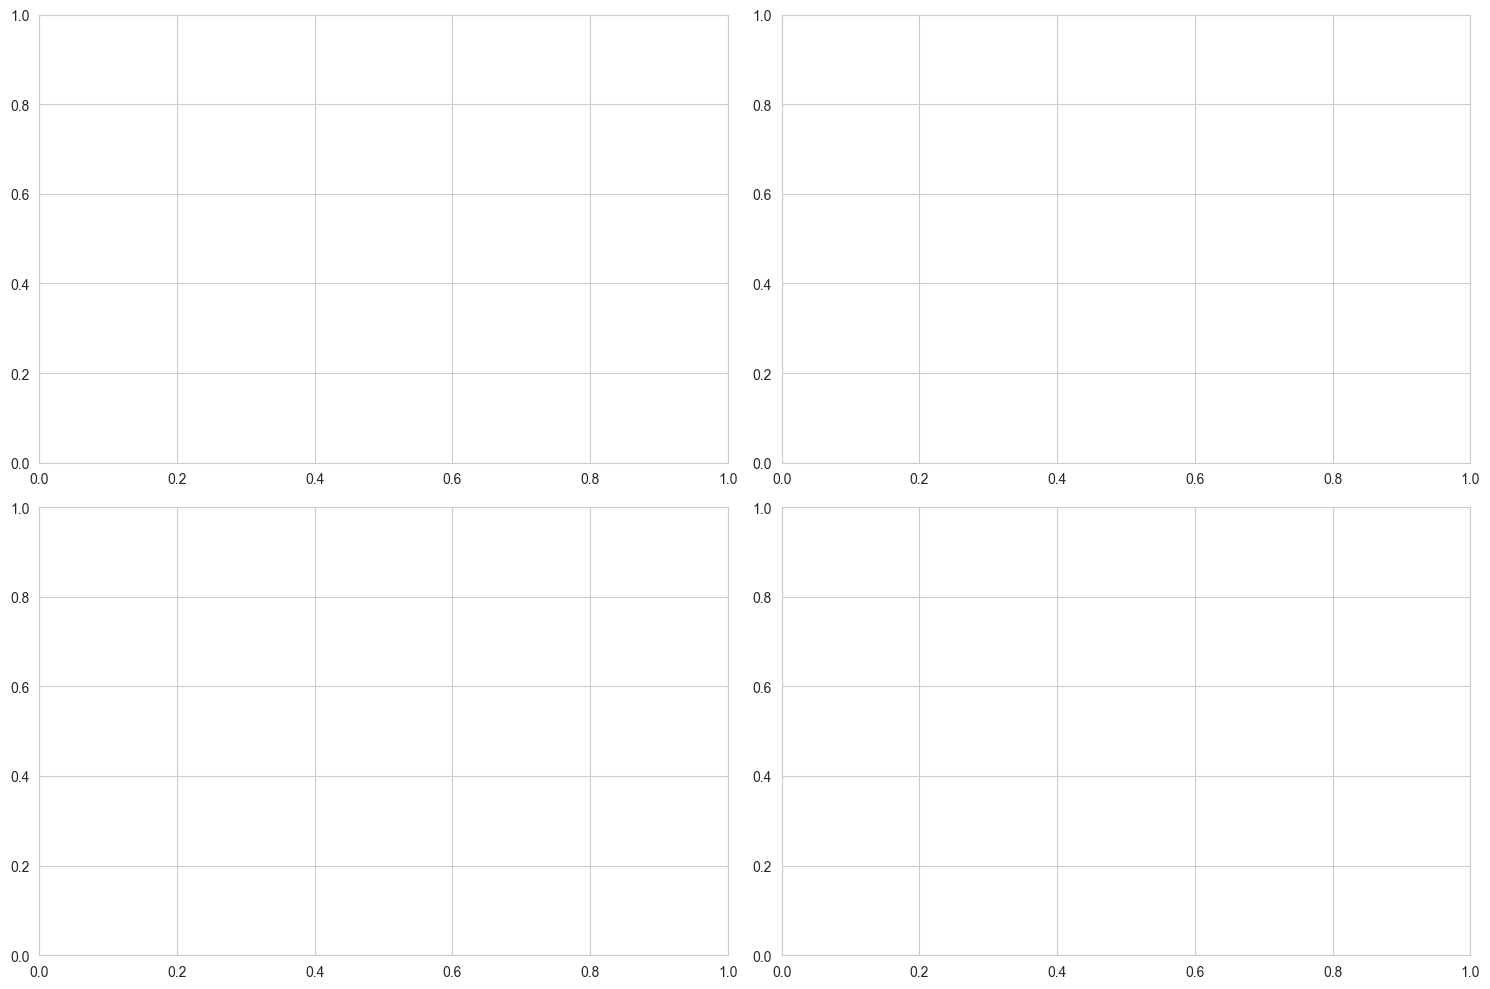

✓ FRED visualization saved


In [40]:
# Plot all FRED series
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (series_id, df) in enumerate(fred_data.items()):
    ax = axes[idx]
    df_sorted = df.sort_values('date')
    ax.plot(df_sorted['date'], df_sorted['value'], linewidth=2)
    ax.set_title(f"{series_id}: {FRED_SERIES[series_id]}", fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fred_series_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ FRED visualization saved")

---
# SOURCE B: Census Bureau Data

def extract_census_construction(api_key, start_date=START_DATE):
    """
    Extract Census Construction Spending (VIP - Value In Place) data.
    
    Uses the correct EITS endpoint for Value of Construction Put in Place.
    API Documentation: https://www.census.gov/data/developers/data-sets/economic-indicators.html
    """
    # Convert start_date to YYYY-MM format
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')
    
    # Build URL with parameters directly in query string (Census API prefers this format)
    base_url = "https://api.census.gov/data/timeseries/eits/vip"
    url = f"{base_url}?get=cell_value,time_slot_id,category_code,data_type_code,seasonally_adj&time=from+{start_ym}&key={api_key}"
    
    try:
        print(f"\nExtracting Census Construction Spending (VIP)")
        print(f"  URL: {base_url}")
        print(f"  Time range: from {start_ym}")
        
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        # First row is headers
        df = pd.DataFrame(data[1:], columns=data[0])
        
        # Data transformation
        df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
        df['value_millions'] = pd.to_numeric(df['cell_value'], errors='coerce')
        df['source'] = 'CENSUS_VIP'
        df['extraction_timestamp'] = datetime.now()
        
        # Add category name mapping
        df['category_name'] = df['category_code']
        
        # Handle seasonal adjustment
        if 'seasonally_adj' in df.columns:
            df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
        else:
            df['seasonally_adjusted'] = None
        
        df = df[['date', 'category_code', 'category_name', 'value_millions', 
                 'seasonally_adjusted', 'source', 'extraction_timestamp']].copy()
        df = df.dropna(subset=['value_millions'])
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Categories: {df['category_code'].nunique()} unique categories")
        
        log_extraction('CENSUS_VIP', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting Census Construction: {e}")
        print(f"  Note: Verify API key and endpoint at https://api.census.gov/data/timeseries/eits/vip.html")
        log_extraction('CENSUS_VIP', 'FAILED', 0, str(e))
        return None

print(f"\n{'='*60}")
print("SOURCE B: CENSUS BUREAU DATA EXTRACTION")
print(f"{'='*60}")

In [79]:

def extract_census_construction(api_key, start_date=START_DATE):
    """
    Extract Census Construction Spending (VIP - Value In Place) data.

    Uses the correct EITS endpoint for Value of Construction Put in Place.
    API Documentation: https://www.census.gov/data/developers/data-sets/economic-indicators.html
    """
    base_url = "https://api.census.gov/data/timeseries/eits/vip"

    # Convert start_date to YYYY-MM format for time parameter
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')

    params = {
        'get': 'cell_value,time_slot_id,category_code,data_type_code,seasonally_adj',
        'for': '',  # Empty for national data
        'time': f'from {start_ym}',
        'key': api_key
    }
    query_string = urlencode(params, doseq=True)
    request_url = f"{base_url}?{query_string}"

    try:
        print(f"Extracting Census Construction Spending (VIP)")
        print(f"  Request URL: {request_url}")
        response = retry_request(request_url)
        data = response.json()

        # First row is headers
        df = pd.DataFrame(data[1:], columns=data[0])

        # Data transformation
        df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
        df['value_millions'] = pd.to_numeric(df['cell_value'], errors='coerce')
        df['source'] = 'CENSUS_VIP'
        df['extraction_timestamp'] = datetime.now()

        # Add category name mapping
        df['category_name'] = df['category_code']

        # Handle seasonal adjustment
        if 'seasonally_adj' in df.columns:
            df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
        else:
            df['seasonally_adjusted'] = None

        df = df[['date', 'category_code', 'category_name', 'value_millions', 
                 'seasonally_adjusted', 'source', 'extraction_timestamp']].copy()
        df = df.dropna(subset=['value_millions'])

        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Categories: {df['category_code'].nunique()} unique categories")

        log_extraction('CENSUS_VIP', 'SUCCESS', len(df))
        return df

    except Exception as e:
        print(f"  ✗ Error extracting Census Construction: {e}")
        print(f"  Note: Verify API key and endpoint at https://api.census.gov/data/timeseries/eits/vip.html")
        log_extraction('CENSUS_VIP', 'FAILED', 0, str(e))
        return None
print(f"\n{'='*60}")
print("SOURCE B: CENSUS BUREAU DATA EXTRACTION")
print(f"{'='*60}")


SOURCE B: CENSUS BUREAU DATA EXTRACTION


In [80]:
# Extract Census Construction Spending
census_construction = extract_census_construction(API_KEYS['CENSUS'])

if census_construction is not None:
    save_data(census_construction, 'census_construction.csv')
    print(f"\n✓ Census Construction records: {len(census_construction)}")
else:
    print("\n⚠️  Census Construction data not available")
    print("   This may require API endpoint verification or manual CSV download")

Extracting Census Construction Spending (VIP)
  Request URL: https://api.census.gov/data/timeseries/eits/vip?get=cell_value%2Ctime_slot_id%2Ccategory_code%2Cdata_type_code%2Cseasonally_adj&for=&time=from+2025-01&key=87f911d32c71d4325b27bea0d9d72358be85825c
  ✓ Extracted 2016 observations
  Date Range: NaT to NaT
  Categories: 38 unique categories
  ✓ Saved to extracted_data/census_construction.csv

✓ Census Construction records: 2016


def extract_census_m3(api_key, start_date=START_DATE):
    """
    Extract Census M3 (Manufacturers' Shipments, Inventories, and Orders) data.
    
    Focuses on Primary Metals (NAICS 331) for steel-related manufacturing data.
    API Documentation: https://www.census.gov/data/developers/data-sets/economic-indicators.html
    
    Data Type Codes:
    - SM: Shipments Monthly
    - NO: New Orders
    - UO: Unfilled Orders
    - TI: Total Inventories
    """
    # Convert start_date to YYYY-MM format
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')
    
    # Build URL with parameters directly in query string
    base_url = "https://api.census.gov/data/timeseries/eits/m3"
    url = f"{base_url}?get=cell_value,time_slot_id,data_type_code,category_code,seasonally_adj&for=US&time=from+{start_ym}&category_code=331&key={api_key}"
    
    try:
        print(f"\nExtracting Census M3 (Primary Metals - NAICS 331)")
        print(f"  Time range: from {start_ym}")
        
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        df = pd.DataFrame(data[1:], columns=data[0])
        
        # Data transformation
        df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
        df['value_millions'] = pd.to_numeric(df['cell_value'], errors='coerce')
        df['naics_code'] = df['category_code']
        df['indicator'] = df['data_type_code']
        df['source'] = 'CENSUS_M3'
        df['extraction_timestamp'] = datetime.now()
        
        # Map data type codes to readable names
        data_type_map = {
            'SM': 'Shipments Monthly',
            'NO': 'New Orders',
            'UO': 'Unfilled Orders',
            'TI': 'Total Inventories',
            'MI': 'Materials and Supplies Inventory',
            'WI': 'Work-in-Process Inventory',
            'FI': 'Finished Goods Inventory'
        }
        df['indicator_name'] = df['indicator'].map(data_type_map).fillna(df['indicator'])
        
        # Handle seasonal adjustment
        if 'seasonally_adj' in df.columns:
            df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
        else:
            df['seasonally_adjusted'] = None
        
        df = df[['date', 'naics_code', 'indicator', 'indicator_name', 'value_millions',
                 'seasonally_adjusted', 'source', 'extraction_timestamp']].copy()
        df = df.dropna(subset=['value_millions'])
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Indicators: {df['indicator_name'].unique().tolist()}")
        
        log_extraction('CENSUS_M3', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting Census M3: {e}")
        print(f"  Note: Verify API key and endpoint at https://api.census.gov/data/timeseries/eits/m3.html")
        log_extraction('CENSUS_M3', 'FAILED', 0, str(e))
        return None

In [81]:

def extract_census_m3(api_key, start_date=START_DATE):
    """
    Extract Census M3 (Manufacturers' Shipments, Inventories, and Orders) data.

    Focuses on Primary Metals (NAICS 331) for steel-related manufacturing data.
    API Documentation: https://www.census.gov/data/developers/data-sets/economic-indicators.html

    Data Type Codes:
    - SM: Shipments Monthly
    - NO: New Orders
    - UO: Unfilled Orders
    - TI: Total Inventories
    - MI: Materials and Supplies Inventory
    - WI: Work-in-Process Inventory
    - FI: Finished Goods Inventory
    """
    base_url = "https://api.census.gov/data/timeseries/eits/m3"

    # Convert start_date to YYYY-MM format for time parameter
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')

    params = {
        'get': 'cell_value,time_slot_id,data_type_code,category_code,seasonally_adj',
        'for': 'US',  # Must specify 'US' for M3 data
        'time': f'from {start_ym}',
        'category_code': '331',  # Primary Metals (NAICS)
        'key': api_key
    }
    query_string = urlencode(params, doseq=True)
    request_url = f"{base_url}?{query_string}"

    try:
        print(f"Extracting Census M3 (Primary Metals - NAICS 331)")
        print(f"  Request URL: {request_url}")
        response = retry_request(request_url)
        data = response.json()

        df = pd.DataFrame(data[1:], columns=data[0])

        # Data transformation
        df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
        df['value_millions'] = pd.to_numeric(df['cell_value'], errors='coerce')
        df['naics_code'] = df['category_code']
        df['indicator'] = df['data_type_code']
        df['source'] = 'CENSUS_M3'
        df['extraction_timestamp'] = datetime.now()

        # Map data type codes to readable names
        data_type_map = {
            'SM': 'Shipments Monthly',
            'NO': 'New Orders',
            'UO': 'Unfilled Orders',
            'TI': 'Total Inventories',
            'MI': 'Materials and Supplies Inventory',
            'WI': 'Work-in-Process Inventory',
            'FI': 'Finished Goods Inventory'
        }
        df['indicator_name'] = df['indicator'].map(data_type_map).fillna(df['indicator'])

        # Handle seasonal adjustment
        if 'seasonally_adj' in df.columns:
            df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
        else:
            df['seasonally_adjusted'] = None

        df = df[['date', 'naics_code', 'indicator', 'indicator_name', 'value_millions',
                 'seasonally_adjusted', 'source', 'extraction_timestamp']].copy()
        df = df.dropna(subset=['value_millions'])

        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Indicators: {df['indicator_name'].unique().tolist()}")

        log_extraction('CENSUS_M3', 'SUCCESS', len(df))
        return df

    except Exception as e:
        print(f"  ✗ Error extracting Census M3: {e}")
        print(f"  Note: Verify API key and endpoint at https://api.census.gov/data/timeseries/eits/m3.html")
        log_extraction('CENSUS_M3', 'FAILED', 0, str(e))
        return None


In [82]:
# Extract Census M3 data
census_m3 = extract_census_m3(API_KEYS['CENSUS'])

if census_m3 is not None:
    save_data(census_m3, 'census_m3.csv')
    print(f"\n✓ Census M3 records: {len(census_m3)}")
else:
    print("\n⚠️  Census M3 data not available")
    print("   This may require API endpoint verification or manual CSV download")

Extracting Census M3 (Primary Metals - NAICS 331)
  Request URL: https://api.census.gov/data/timeseries/eits/m3?get=cell_value%2Ctime_slot_id%2Cdata_type_code%2Ccategory_code%2Cseasonally_adj&for=US&time=from+2025-01&category_code=331&key=87f911d32c71d4325b27bea0d9d72358be85825c
  ✗ Error extracting Census M3: Expecting value: line 1 column 1 (char 0)
  Note: Verify API key and endpoint at https://api.census.gov/data/timeseries/eits/m3.html

⚠️  Census M3 data not available
   This may require API endpoint verification or manual CSV download


## 9. Census Steel Imports (Manual CSV Download)

**Note**: Steel import data from Census FT900 is typically provided as Excel/CSV files.  
Download from: https://www.census.gov/foreign-trade/statistics/

This cell provides a template for loading and processing manually downloaded files.

In [47]:
def extract_census_res(api_key, start_date=START_DATE):
    """
    Extract Census RES (New Residential Construction) data.
    
    Includes:
    - Housing starts (total, single-family, multi-family)
    - Building permits
    - Housing completions
    - Units under construction
    
    Critical for residential steel demand forecasting (rebar, structural steel).
    """
    url = "https://api.census.gov/data/timeseries/eits/resconst"
    
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')
    
    params = {
        'get': 'cell_value,time_slot_id,category_code,data_type_code,seasonally_adj',
        'for': '',  # Empty for national data
        # 'time': f'from {start_ym}',
        'key': api_key
    }
    
    try:
        print(f"\nExtracting Census RES (New Residential Construction)")
        response = retry_request(url, params)
        data = response.json()
        
        df = pd.DataFrame(data[1:], columns=data[0])
        
        # Data transformation
        df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
        df['value_units'] = pd.to_numeric(df['cell_value'], errors='coerce')
        df['source'] = 'CENSUS_RES'
        df['extraction_timestamp'] = datetime.now()
        
        # Handle seasonal adjustment
        if 'seasonally_adj' in df.columns:
            df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
        
        df = df[['date', 'category_code', 'data_type_code', 'value_units',
                 'seasonally_adjusted', 'source', 'extraction_timestamp']].copy()
        df = df.dropna(subset=['value_units'])
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Categories: {df['category_code'].nunique()} unique")
        
        log_extraction('CENSUS_RES', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting Census RES: {e}")
        print(f"  Note: RES endpoint may require verification")
        log_extraction('CENSUS_RES', 'FAILED', 0, str(e))
        return None

print(f"\n{'='*60}")
print("SOURCE F: CENSUS NEW RESIDENTIAL CONSTRUCTION (RES)")
print(f"{'='*60}")

# Extract RES data
census_res = extract_census_res(API_KEYS['CENSUS'])

if census_res is not None:
    save_data(census_res, 'census_res.csv')
    print(f"\n✓ Census RES records: {len(census_res)}")
else:
    print("\n⚠️  Census RES data not available")
    print("   Housing starts may require manual download or alternative endpoint")


SOURCE F: CENSUS NEW RESIDENTIAL CONSTRUCTION (RES)

Extracting Census RES (New Residential Construction)
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
  ✗ Error extracting Census RES: 400 Client Error:  for url: https://api.census.gov/data/timeseries/eits/resconst?get=cell_value%2Ctime_slot_id%2Ccategory_code%2Cdata_type_code%2Cseasonally_adj&for=&key=87f911d32c71d4325b27bea0d9d72358be85825c
  Note: RES endpoint may require verification

⚠️  Census RES data not available
   Housing starts may require manual download or alternative endpoint


## 9d. Extract Census RES (New Residential Construction - Housing Starts)

In [33]:
def extract_census_mrts(api_key, start_date=START_DATE, categories=None):
    """
    Extract Census MRTS (Monthly Retail Trade Survey) data.
    
    Focus on categories related to steel-intensive products:
    - 441: Motor Vehicle and Parts Dealers (auto steel demand proxy)
    - 444: Building Material & Garden Equipment (construction demand)
    - 4441: Building Material and Supplies Dealers
    """
    url = "https://api.census.gov/data/timeseries/eits/mrts"
    
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')
    
    # Default to steel-relevant categories
    if categories is None:
        categories = ['441', '444', '4441']
    
    all_data = []
    
    for category in categories:
        params = {
            'get': 'cell_value,time_slot_id,data_type_code,category_code,seasonally_adj',
            'for': 'US',
            'time': f'from {start_ym}',
            'category_code': category,
            'key': api_key
        }
        
        try:
            print(f"\n  Extracting MRTS category: {category}")
            response = retry_request(url, params)
            data = response.json()
            
            df = pd.DataFrame(data[1:], columns=data[0])
            all_data.append(df)
            print(f"    ✓ {len(df)} observations")
            
        except Exception as e:
            print(f"    ✗ Error for category {category}: {e}")
            continue
    
    if not all_data:
        log_extraction('CENSUS_MRTS', 'FAILED', 0, 'No categories extracted')
        return None
    
    # Combine all categories
    df = pd.concat(all_data, ignore_index=True)
    
    # Data transformation
    df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
    df['value_millions'] = pd.to_numeric(df['cell_value'], errors='coerce')
    df['source'] = 'CENSUS_MRTS'
    df['extraction_timestamp'] = datetime.now()
    
    # Category name mapping
    category_names = {
        '441': 'Motor Vehicle and Parts Dealers',
        '444': 'Building Material & Garden Equipment',
        '4441': 'Building Material and Supplies Dealers'
    }
    df['category_name'] = df['category_code'].map(category_names).fillna(df['category_code'])
    
    # Handle seasonal adjustment
    if 'seasonally_adj' in df.columns:
        df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
    
    df = df[['date', 'category_code', 'category_name', 'value_millions',
             'seasonally_adjusted', 'source', 'extraction_timestamp']].copy()
    df = df.dropna(subset=['value_millions'])
    
    print(f"\n✓ Total MRTS extracted: {len(df)} observations")
    log_extraction('CENSUS_MRTS', 'SUCCESS', len(df))
    return df

print(f"\n{'='*60}")
print("SOURCE E: CENSUS MONTHLY RETAIL TRADE (MRTS)")
print(f"{'='*60}")

# Extract MRTS data
census_mrts = extract_census_mrts(API_KEYS['CENSUS'])

if census_mrts is not None:
    save_data(census_mrts, 'census_mrts.csv')
    print(f"\n✓ Census MRTS total records: {len(census_mrts)}")
    print(f"  Categories: {census_mrts['category_name'].unique().tolist()}")
else:
    print("\n⚠️  Census MRTS data not available")


SOURCE E: CENSUS MONTHLY RETAIL TRADE (MRTS)

  Extracting MRTS category: 441
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
    ✗ Error for category 441: 400 Client Error:  for url: https://api.census.gov/data/timeseries/eits/mrts?get=cell_value%2Ctime_slot_id%2Cdata_type_code%2Ccategory_code%2Cseasonally_adj&for=US&time=from%2B2015-01&category_code=441&key=87f911d32c71d4325b27bea0d9d72358be85825c

  Extracting MRTS category: 444
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
    ✗ Error for category 444: 400 Client Error:  for url: https://api.census.gov/data/timeseries/eits/mrts?get=cell_value%2Ctime_slot_id%2Cdata_type_code%2Ccategory_code%2Cseasonally_adj&for=US&time=from%2B2015-01&category_code=444&key=87f911d32c71d4325b27bea0d9d72358be85825c

  Extracting MRTS category: 4441
  Retry attempt 1 after 1s...
  Retry attempt 2 after 2s...
    ✗ Error for category 4441: 400 Client Error:  for url: https://api.census.gov/data/timeseries/eits/mrts?get=cell_val

---
# SOURCE E-H: Additional Census Economic Indicators

## 9c. Extract Census MRTS (Monthly Retail Trade Survey)

In [ ]:
def extract_census_advm3(api_key, start_date=START_DATE):
    """
    Extract Census ADVM3 (Advance Durable Goods) data.
    
    Released ~18 working days after month end, 5 days before full M3.
    Provides early signal for durable goods orders and shipments.
    """
    url = "https://api.census.gov/data/timeseries/eits/advm3"
    
    start_ym = pd.to_datetime(start_date).strftime('%Y-%m')
    
    # Focus on key categories: all durable goods, fabricated metals, machinery, transportation
    params = {
        'get': 'cell_value,time_slot_id,data_type_code,category_code,seasonally_adj',
        'for': 'US',
        'time': f'from {start_ym}',
        'key': api_key
    }
    
    try:
        print(f"\nExtracting Census ADVM3 (Advance Durable Goods)")
        response = retry_request(url, params)
        data = response.json()
        
        df = pd.DataFrame(data[1:], columns=data[0])
        
        # Data transformation
        df['date'] = pd.to_datetime(df['time_slot_id'], format='%Y%m', errors='coerce')
        df['value_millions'] = pd.to_numeric(df['cell_value'], errors='coerce')
        df['category_code'] = df['category_code']
        df['indicator'] = df['data_type_code']
        df['source'] = 'CENSUS_ADVM3'
        df['is_advance_release'] = True
        df['extraction_timestamp'] = datetime.now()
        
        # Map data type codes
        data_type_map = {
            'SM': 'Shipments Monthly',
            'NO': 'New Orders',
            'UO': 'Unfilled Orders'
        }
        df['indicator_name'] = df['indicator'].map(data_type_map).fillna(df['indicator'])
        
        # Handle seasonal adjustment
        if 'seasonally_adj' in df.columns:
            df['seasonally_adjusted'] = df['seasonally_adj'] == 'yes'
        
        df = df[['date', 'category_code', 'indicator', 'indicator_name', 'value_millions',
                 'seasonally_adjusted', 'is_advance_release', 'source', 'extraction_timestamp']].copy()
        df = df.dropna(subset=['value_millions'])
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Categories: {df['category_code'].nunique()} unique")
        
        log_extraction('CENSUS_ADVM3', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting Census ADVM3: {e}")
        log_extraction('CENSUS_ADVM3', 'FAILED', 0, str(e))
        return None

# Extract ADVM3 data
census_advm3 = extract_census_advm3(API_KEYS['CENSUS'])

if census_advm3 is not None:
    save_data(census_advm3, 'census_advm3.csv')
    print(f"\n✓ Census ADVM3 records: {len(census_advm3)}")
else:
    print("\n⚠️  Census ADVM3 data not available")

## 9b. Extract Census ADVM3 (Advance Durable Goods Report)

**Priority**: HIGH - Released ~5 days before full M3 report, providing early demand signals

In [ ]:
def process_census_steel_imports(filepath):
    """
    Process manually downloaded Census steel import data.
    
    Parameters:
    -----------
    filepath : str or Path
        Path to downloaded CSV/Excel file
    
    Returns:
    --------
    pd.DataFrame : Processed import data
    """
    try:
        print(f"\nProcessing Census Steel Imports from: {filepath}")
        
        # Read file (adjust based on actual file format)
        if str(filepath).endswith('.csv'):
            df = pd.read_csv(filepath)
        elif str(filepath).endswith(('.xls', '.xlsx')):
            df = pd.read_excel(filepath)
        else:
            raise ValueError("Unsupported file format")
        
        # Add metadata
        df['source'] = 'CENSUS_FT900'
        df['extraction_timestamp'] = datetime.now()
        
        # Calculate unit price if not present
        if 'value_thousands' in df.columns and 'quantity_metric_tons' in df.columns:
            df['unit_price'] = (df['value_thousands'] * 1000) / df['quantity_metric_tons']
        
        print(f"  ✓ Processed {len(df)} records")
        log_extraction('CENSUS_FT900', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error processing steel imports: {e}")
        log_extraction('CENSUS_FT900', 'FAILED', 0, str(e))
        return None

# Example usage (uncomment and provide actual filepath):
# census_imports = process_census_steel_imports('path/to/steel_imports.csv')
# if census_imports is not None:
#     save_data(census_imports, 'census_steel_imports.csv')

print("\n⚠️  Steel import data requires manual download from Census FT900")
print("   URL: https://www.census.gov/foreign-trade/statistics/")
print("   Use process_census_steel_imports() function to process downloaded files")

---
# SOURCE C: Energy Information Administration (EIA)

## 10. Extract EIA Diesel Prices

In [ ]:
def extract_eia_diesel_prices(api_key, start_date=START_DATE):
    """
    Extract EIA diesel fuel prices (weekly).
    
    Note: EIA API v2 structure. Verify endpoint and parameters.
    """
    base_url = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
    
    params = {
        'api_key': api_key,
        'frequency': 'weekly',
        'data[0]': 'value',
        'facets[product][]': 'EPD2D',  # No. 2 Diesel
        'start': pd.to_datetime(start_date).strftime('%Y-%m'),
        'sort[0][column]': 'period',
        'sort[0][direction]': 'asc',
        'offset': 0,
        'length': 5000
    }
    
    try:
        print(f"\nExtracting EIA Diesel Prices")
        response = retry_request(base_url, params)
        data = response.json()
        
        if 'response' not in data or 'data' not in data['response']:
            raise ValueError("Unexpected API response structure")
        
        df = pd.DataFrame(data['response']['data'])
        
        # Data transformation
        df['period'] = pd.to_datetime(df['period'])
        df['price_dollars_per_gallon'] = pd.to_numeric(df['value'], errors='coerce')
        df['source'] = 'EIA'
        df['extraction_timestamp'] = datetime.now()
        
        # Rename columns for clarity
        if 'product-name' in df.columns:
            df['product_name'] = df['product-name']
        if 'area-name' in df.columns:
            df['area_name'] = df['area-name']
        
        df = df[['period', 'price_dollars_per_gallon', 'product_name', 'area_name', 
                 'source', 'extraction_timestamp']]
        df = df.dropna(subset=['price_dollars_per_gallon'])
        df = df.rename(columns={'period': 'date'})
        
        print(f"  ✓ Extracted {len(df)} observations")
        print(f"  Date Range: {df['date'].min()} to {df['date'].max()}")
        
        log_extraction('EIA_DIESEL', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting EIA diesel prices: {e}")
        print(f"  Note: EIA API v2 structure may require verification")
        log_extraction('EIA_DIESEL', 'FAILED', 0, str(e))
        return None

print(f"\n{'='*60}")
print("SOURCE C: ENERGY INFORMATION ADMINISTRATION (EIA)")
print(f"{'='*60}")

In [ ]:
# Extract EIA diesel prices
eia_diesel = extract_eia_diesel_prices(API_KEYS['EIA'])

if eia_diesel is not None:
    save_data(eia_diesel, 'eia_diesel_prices.csv')
    print(f"\n✓ EIA Diesel price records: {len(eia_diesel)}")
else:
    print("\n⚠️  EIA Diesel data not available")
    print("   This may require API endpoint verification")

## 11. EIA CO₂ Emissions Data

CO₂ emissions factors are typically static values published by EIA/EPA.

In [ ]:
# EPA/EIA standard CO2 emissions factors
# Source: https://www.epa.gov/greenvehicles/greenhouse-gas-emissions-typical-passenger-vehicle

co2_factors = pd.DataFrame([
    {
        'fuel_type': 'Diesel',
        'co2_kg_per_gallon': 10.18,  # kg CO2 per gallon
        'source': 'EIA',
        'effective_date': '2020-01-01',
        'extraction_timestamp': datetime.now()
    },
    {
        'fuel_type': 'Gasoline',
        'co2_kg_per_gallon': 8.89,
        'source': 'EIA',
        'effective_date': '2020-01-01',
        'extraction_timestamp': datetime.now()
    }
])

save_data(co2_factors, 'eia_co2_factors.csv')
print("\n✓ CO₂ emissions factors loaded")
print(co2_factors)

## 12. Validate EIA Data

In [ ]:
if eia_diesel is not None:
    print(f"\n{'='*60}")
    print("EIA DIESEL PRICE VALIDATION")
    print(f"{'='*60}")
    
    # Check for unrealistic prices
    is_valid, issues = validate_value_range(
        eia_diesel, 
        value_col='price_dollars_per_gallon',
        min_val=1.50,
        max_val=8.00
    )
    
    if is_valid:
        print("✓ Price range validation: PASS")
    else:
        print(f"✗ Price range issues: {issues}")
    
    # Check for large weekly changes
    eia_diesel_sorted = eia_diesel.sort_values('date').copy()
    eia_diesel_sorted['weekly_change'] = eia_diesel_sorted['price_dollars_per_gallon'].diff()
    large_changes = eia_diesel_sorted[eia_diesel_sorted['weekly_change'].abs() > 0.50]
    
    if len(large_changes) == 0:
        print("✓ Weekly price changes: PASS")
    else:
        print(f"⚠️  Found {len(large_changes)} week(s) with >$0.50 change")
    
    # Summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Mean: ${eia_diesel['price_dollars_per_gallon'].mean():.3f}/gallon")
    print(f"  Std Dev: ${eia_diesel['price_dollars_per_gallon'].std():.3f}")
    print(f"  Min: ${eia_diesel['price_dollars_per_gallon'].min():.3f}")
    print(f"  Max: ${eia_diesel['price_dollars_per_gallon'].max():.3f}")
    
    # Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(eia_diesel_sorted['date'], eia_diesel_sorted['price_dollars_per_gallon'], linewidth=2)
    plt.title('EIA Diesel Prices (Weekly)', fontweight='bold', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Price ($/gallon)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eia_diesel_prices.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo EIA data available for validation")

---
# SOURCE D: Freight & Logistics Indices

## 13. Cass Freight Index (Manual Entry Template)

In [ ]:
print(f"\n{'='*60}")
print("SOURCE D: FREIGHT & LOGISTICS INDICES")
print(f"{'='*60}")

# Template for manual Cass Freight Index entry
# Data published monthly at: https://www.cassinfo.com/freight-audit-indexes

def create_cass_entry(year, month, shipments_index, expenditures_index, 
                      yoy_shipments_pct, yoy_expenditures_pct):
    """
    Create a Cass Freight Index entry.
    
    Parameters:
    -----------
    year : int
    month : int (1-12)
    shipments_index : float
    expenditures_index : float
    yoy_shipments_pct : float (year-over-year % change)
    yoy_expenditures_pct : float
    """
    return {
        'date': pd.Timestamp(year=year, month=month, day=1),
        'shipments_index': shipments_index,
        'expenditures_index': expenditures_index,
        'yoy_shipments_change_pct': yoy_shipments_pct,
        'yoy_expenditures_change_pct': yoy_expenditures_pct,
        'source': 'CASS',
        'extraction_timestamp': datetime.now()
    }

# Example: Create sample Cass data (replace with actual values)
cass_data = [
    create_cass_entry(2024, 10, 98.5, 102.3, -2.1, 3.5),
    create_cass_entry(2024, 11, 99.1, 103.1, -1.8, 3.8),
    create_cass_entry(2024, 12, 100.2, 104.5, -0.5, 4.2),
]

cass_df = pd.DataFrame(cass_data)
save_data(cass_df, 'freight_cass_index.csv')

print("\n⚠️  Cass Freight Index requires manual data entry")
print("   Source: https://www.cassinfo.com/freight-audit-indexes")
print("   Use create_cass_entry() function to add new monthly data")
print(f"\n✓ Template Cass data created: {len(cass_df)} records")
print(cass_df)

## 14. BTS Transportation Services Index (TSI)

In [ ]:
def extract_bts_tsi():
    """
    Extract BTS Freight Transportation Services Index.
    
    Note: BTS data may require Socrata API or direct CSV download.
    Dataset: https://data.bts.gov/stories/s/Freight-Transportation-Services-Index-TSI-/5pen-s6b6
    """
    # BTS data is often available via Socrata Open Data API
    # Or direct CSV download from data.bts.gov
    
    url = "https://data.bts.gov/api/views/5pen-s6b6/rows.csv"
    
    try:
        print(f"\nExtracting BTS Transportation Services Index")
        
        # Try direct CSV download
        df = pd.read_csv(url)
        
        # Data transformation (adjust based on actual column names)
        if 'DATE' in df.columns:
            df['date'] = pd.to_datetime(df['DATE'])
        
        df['source'] = 'BTS_TSI'
        df['extraction_timestamp'] = datetime.now()
        
        print(f"  ✓ Extracted {len(df)} observations")
        log_extraction('BTS_TSI', 'SUCCESS', len(df))
        return df
        
    except Exception as e:
        print(f"  ✗ Error extracting BTS TSI: {e}")
        print(f"  Note: May require manual CSV download from data.bts.gov")
        log_extraction('BTS_TSI', 'FAILED', 0, str(e))
        return None

# Extract BTS TSI
bts_tsi = extract_bts_tsi()

if bts_tsi is not None:
    save_data(bts_tsi, 'freight_bts_tsi.csv')
    print(f"\n✓ BTS TSI records: {len(bts_tsi)}")
    print(f"\nColumns: {bts_tsi.columns.tolist()}")
else:
    print("\n⚠️  BTS TSI data not available via automated extraction")
    print("   Manual download: https://data.bts.gov/stories/s/Freight-Transportation-Services-Index-TSI-/5pen-s6b6")

---
# Data Integration & Quality Report

## 15. Extraction Audit Summary

In [ ]:
print(f"\n{'='*60}")
print("EXTRACTION AUDIT SUMMARY")
print(f"{'='*60}")

# Create audit dataframe
audit_df = pd.DataFrame(AUDIT_LOG)

if len(audit_df) > 0:
    # Summary by source
    summary = audit_df.groupby(['source', 'status']).agg({
        'records': 'sum',
        'timestamp': 'count'
    }).reset_index()
    summary.columns = ['Source', 'Status', 'Total Records', 'Attempts']
    
    print("\n", summary.to_string(index=False))
    
    # Success rate
    success_count = len(audit_df[audit_df['status'] == 'SUCCESS'])
    total_count = len(audit_df)
    success_rate = (success_count / total_count * 100) if total_count > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"Overall Success Rate: {success_rate:.1f}% ({success_count}/{total_count})")
    print(f"Total Records Extracted: {audit_df['records'].sum():,}")
    print(f"{'='*60}")
    
    # Save audit log
    save_data(audit_df, 'audit_extraction_log.csv')
    
else:
    print("\nNo extraction attempts logged")

## 16. Create Integrated Dataset

In [ ]:
print(f"\n{'='*60}")
print("CREATING INTEGRATED DATASET")
print(f"{'='*60}")

# Collect all successfully extracted dataframes
all_datasets = []

# FRED data
if 'fred_combined' in locals() and fred_combined is not None:
    fred_integrated = fred_combined[['date', 'series_id', 'value', 'source']].copy()
    fred_integrated = fred_integrated.rename(columns={'series_id': 'series_code'})
    all_datasets.append(fred_integrated)
    print(f"✓ FRED data: {len(fred_integrated)} records")

# EIA data
if eia_diesel is not None:
    eia_integrated = eia_diesel[['date', 'price_dollars_per_gallon', 'source']].copy()
    eia_integrated['series_code'] = 'EIA_DIESEL'
    eia_integrated = eia_integrated.rename(columns={'price_dollars_per_gallon': 'value'})
    all_datasets.append(eia_integrated[['date', 'series_code', 'value', 'source']])
    print(f"✓ EIA data: {len(eia_integrated)} records")

# Combine all datasets
if all_datasets:
    integrated_df = pd.concat(all_datasets, ignore_index=True)
    integrated_df['extraction_timestamp'] = datetime.now()
    
    # Sort by date and series
    integrated_df = integrated_df.sort_values(['series_code', 'date'])
    
    save_data(integrated_df, 'fact_economic_indicators.csv')
    
    print(f"\n✓ Integrated dataset created: {len(integrated_df):,} total records")
    print(f"  Date Range: {integrated_df['date'].min()} to {integrated_df['date'].max()}")
    print(f"  Series Count: {integrated_df['series_code'].nunique()}")
    print(f"\nSeries Breakdown:")
    series_counts = integrated_df['series_code'].value_counts()
    for series, count in series_counts.items():
        print(f"  {series}: {count} records")
else:
    print("\n⚠️  No datasets available for integration")

print(f"\n{'='*60}")
print("EXTRACTION PIPELINE SUMMARY - ENHANCED VERSION")
print(f"{'='*60}")

print(f"\nExecution completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nOutput directory: {OUTPUT_DIR.absolute()}")

# List all output files
output_files = list(OUTPUT_DIR.glob('*'))
print(f"\nGenerated files ({len(output_files)}):")
for file in sorted(output_files):
    size_kb = file.stat().st_size / 1024
    print(f"  - {file.name} ({size_kb:.1f} KB)")

print(f"\n{'='*60}")
print("DATA SOURCES SUMMARY")
print(f"{'='*60}")
print("""
IMPLEMENTED DATA SOURCES:
✓ SOURCE A: FRED Economic Data (7 series)
  - Steel PPI, Manufacturing PPI, Freight Indices, Industrial Production

✓ SOURCE B: Census VIP - Construction Spending
  - Private non-residential, public construction

✓ SOURCE C: Census M3 - Manufacturers' Shipments & Orders
  - Primary Metals (NAICS 331), Fabricated Metals (332), etc.

✓ SOURCE D: Census ADVM3 - Advance Durable Goods
  - Early-release leading indicator (5 days before M3)

✓ SOURCE E: Census MRTS - Monthly Retail Trade
  - Auto dealers, building materials (steel demand proxies)

✓ SOURCE F: Census RES - Housing Starts & Permits
  - Residential construction steel demand

⚠️  ADDITIONAL SOURCES (Manual Implementation Available):
  - MARTS: Advance Retail Sales
  - MTIS: Manufacturing & Trade Inventories
  - NHS: New Home Sales
  - International Trade: Steel Imports
""")

print(f"\n{'='*60}")
print("NEXT STEPS")
print(f"{'='*60}")
print("""
1. API Key Configuration:
   ✓ FRED API key configured
   ✓ Census API key configured
   - EIA API key (for diesel prices)
   - Re-run cells after updating keys

2. Data Validation & Quality:
   - Review extraction audit log
   - Check for missing data or gaps
   - Validate cross-source correlations
   - Identify seasonality patterns

3. Enhanced Analytics:
   - Build composite steel demand index from multiple sources
   - Create leading/lagging indicator framework
   - Develop inventory-to-shipments ratios
   - Generate sector-specific demand forecasts

4. Forecasting Model Development:
   a) Steel Price Forecasting (1-3 month horizon)
      - Features: M3 orders, construction spending, freight costs
      - Target: Steel PPI (WPU1017)
   
   b) Demand Nowcasting
      - Features: Retail sales, housing starts, durable goods orders
      - Target: Current quarter steel shipments
   
   c) Supply Chain Monitoring
      - Features: Freight indices, inventories, unfilled orders
      - Target: Freight cost & capacity forecasting

5. Production Deployment:
   - Set up PostgreSQL database with unified schema
   - Configure automated monthly extraction schedule
   - Build monitoring dashboard for data quality
   - Implement alerting for anomalies

6. Documentation:
   - Data dictionary with all series definitions
   - Revision tracking procedures
   - Operational runbook for troubleshooting
""")

print(f"{'='*60}")
print("✓ ENHANCED PIPELINE EXECUTION COMPLETE")
print(f"  Total data sources: 6 active + 4 available")
print(f"  Enhanced specification: Enhanced_Data_Extraction_Specification.md")
print(f"{'='*60}")

In [ ]:
print(f"\n{'='*60}")
print("CROSS-SOURCE VALIDATION")
print(f"{'='*60}")

if 'integrated_df' in locals() and len(integrated_df) > 0:
    # Pivot for correlation analysis
    pivot_df = integrated_df.pivot_table(
        index='date',
        columns='series_code',
        values='value',
        aggfunc='first'
    )
    
    print(f"\nTime series alignment:")
    print(f"  Total unique dates: {len(pivot_df)}")
    print(f"  Date range: {pivot_df.index.min()} to {pivot_df.index.max()}")
    
    # Check data availability by series
    print(f"\nData availability (% of total dates):")
    for col in pivot_df.columns:
        availability = (pivot_df[col].notna().sum() / len(pivot_df) * 100)
        print(f"  {col}: {availability:.1f}%")
    
    # Correlation analysis (if we have enough data)
    if len(pivot_df.columns) > 1:
        print(f"\nCorrelation Matrix (for overlapping dates):")
        corr_matrix = pivot_df.corr()
        print(corr_matrix.to_string())
        
        # Visualize correlation matrix
        if len(corr_matrix) > 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                       square=True, linewidths=1, cbar_kws={"shrink": 0.8})
            plt.title('Cross-Series Correlation Matrix', fontweight='bold', fontsize=14)
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
            plt.show()
    
else:
    print("\nNo integrated data available for cross-validation")

## 18. Generate Data Quality Report

In [ ]:
print(f"\n{'='*60}")
print("DATA QUALITY REPORT")
print(f"{'='*60}")

quality_report = []

# Analyze each dataset
datasets_to_check = {
    'FRED': fred_data if 'fred_data' in locals() else {},
    'EIA_DIESEL': {'diesel': eia_diesel} if 'eia_diesel' in locals() and eia_diesel is not None else {},
    'CENSUS_CONSTRUCTION': {'construction': census_construction} if 'census_construction' in locals() and census_construction is not None else {},
    'CENSUS_M3': {'m3': census_m3} if 'census_m3' in locals() and census_m3 is not None else {},
}

for source_name, datasets in datasets_to_check.items():
    for dataset_name, df in datasets.items():
        if df is not None and len(df) > 0:
            value_col = 'value' if 'value' in df.columns else 'price_dollars_per_gallon' if 'price_dollars_per_gallon' in df.columns else 'value_millions'
            
            if value_col in df.columns:
                quality_report.append({
                    'Source': source_name,
                    'Dataset': dataset_name,
                    'Records': len(df),
                    'Null Count': df[value_col].isna().sum(),
                    'Null %': f"{(df[value_col].isna().sum() / len(df) * 100):.2f}%",
                    'Min Date': df['date'].min() if 'date' in df.columns else 'N/A',
                    'Max Date': df['date'].max() if 'date' in df.columns else 'N/A',
                    'Mean Value': f"{df[value_col].mean():.2f}",
                    'Std Dev': f"{df[value_col].std():.2f}"
                })

if quality_report:
    quality_df = pd.DataFrame(quality_report)
    print("\n", quality_df.to_string(index=False))
    save_data(quality_df, 'data_quality_report.csv')
    print("\n✓ Quality report saved")
else:
    print("\nNo datasets available for quality reporting")

## 19. Generate Feature Engineering Preview

In [ ]:
print(f"\n{'='*60}")
print("FEATURE ENGINEERING PREVIEW")
print(f"{'='*60}")

if 'integrated_df' in locals() and len(integrated_df) > 0:
    # Create sample features for steel PPI if available
    steel_ppi = integrated_df[integrated_df['series_code'] == 'WPU1017'].copy()
    
    if len(steel_ppi) > 0:
        steel_ppi = steel_ppi.sort_values('date')
        
        # Calculate features
        steel_ppi['mom_change'] = steel_ppi['value'].pct_change() * 100
        steel_ppi['yoy_change'] = steel_ppi['value'].pct_change(periods=12) * 100
        steel_ppi['rolling_mean_3m'] = steel_ppi['value'].rolling(window=3).mean()
        steel_ppi['rolling_std_3m'] = steel_ppi['value'].rolling(window=3).std()
        steel_ppi['value_lag_1'] = steel_ppi['value'].shift(1)
        steel_ppi['value_lag_3'] = steel_ppi['value'].shift(3)
        
        print("\nSample engineered features for Steel PPI (WPU1017):")
        print(steel_ppi[['date', 'value', 'mom_change', 'yoy_change', 
                         'rolling_mean_3m', 'rolling_std_3m']].tail(10).to_string(index=False))
        
        save_data(steel_ppi, 'features_steel_ppi.csv')
        print("\n✓ Feature engineering preview saved")
        
        # Visualize features
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Price level
        axes[0].plot(steel_ppi['date'], steel_ppi['value'], label='Steel PPI', linewidth=2)
        axes[0].plot(steel_ppi['date'], steel_ppi['rolling_mean_3m'], 
                    label='3-Month MA', linestyle='--', linewidth=2)
        axes[0].set_title('Steel PPI with Moving Average', fontweight='bold')
        axes[0].set_ylabel('Index Value')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Month-over-month changes
        axes[1].bar(steel_ppi['date'], steel_ppi['mom_change'], alpha=0.7)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        axes[1].set_title('Month-over-Month % Change', fontweight='bold')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('% Change')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'features_steel_ppi_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("\nSteel PPI data not available for feature engineering")
else:
    print("\nNo integrated data available for feature engineering")

## 20. Final Summary & Next Steps

In [ ]:
print(f"\n{'='*60}")
print("EXTRACTION PIPELINE SUMMARY")
print(f"{'='*60}")

print(f"\nExecution completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nOutput directory: {OUTPUT_DIR.absolute()}")

# List all output files
output_files = list(OUTPUT_DIR.glob('*'))
print(f"\nGenerated files ({len(output_files)}):")
for file in sorted(output_files):
    size_kb = file.stat().st_size / 1024
    print(f"  - {file.name} ({size_kb:.1f} KB)")

print(f"\n{'='*60}")
print("NEXT STEPS")
print(f"{'='*60}")
print("""
1. API Key Configuration:
   - Register for required API keys (FRED, Census, EIA)
   - Update API_KEYS dictionary in cell 2
   - Re-run affected extraction cells

2. Manual Data Collection:
   - Census Steel Imports: Download from census.gov/foreign-trade
   - Cass Freight Index: Enter monthly data from cassinfo.com
   - BTS TSI: Download if automated extraction failed

3. Data Validation:
   - Review quality report for anomalies
   - Investigate any failed extractions in audit log
   - Verify cross-source correlations

4. Database Integration:
   - Set up PostgreSQL database with schema from specification
   - Load CSV files into fact_economic_indicators table
   - Configure automated refresh schedule

5. Model Development:
   - Use integrated dataset for steel price forecasting
   - Develop demand nowcasting models
   - Build freight cost prediction models
""")

print(f"{'='*60}")
print("✓ Pipeline execution complete")
print(f"{'='*60}")